In [10]:
%matplotlib inline
import joblib
import optuna
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import set_config
from tempfile import TemporaryDirectory
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import StackingClassifier
import xgboost as xgb
from xgboost import XGBClassifier
#from lightgbm import LGBMClassifier
#from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn import metrics
import seaborn as sns
import numpy as np
import warnings

In [11]:
target_column = "health_condition"

In [12]:
df = pd.read_csv("data/train.csv")
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       690088 non-null  int64  
 1   health_condition         690088 non-null  str    
 2   sleep_duration           614089 non-null  float64
 3   heart_rate               682255 non-null  float64
 4   bmi                      676190 non-null  float64
 5   calorie_expenditure      637235 non-null  float64
 6   step_count               676172 non-null  float64
 7   exercise_duration        683187 non-null  float64
 8   water_intake             646611 non-null  float64
 9   diet_type                683187 non-null  str    
 10  stress_level             607277 non-null  str    
 11  sleep_quality            631757 non-null  str    
 12  physical_activity_level  653467 non-null  str    
 13  smoking_alcohol          661506 non-null  str    
 14  gender         

In [13]:
df['diet_type'] = df['diet_type'].astype('category')
df['stress_level'] = df['stress_level'].replace({'low':0, 'medium':1, 'high':2})
df['sleep_quality'] = df['sleep_quality'].replace({'poor':0, 'average':1, 'good':2})
df['physical_activity_level'] = df['physical_activity_level'].replace({'sedentary':0, 'moderate':1, 'active':2})
df['smoking_alcohol'] = df['smoking_alcohol'].replace({'no':0, 'occasional':1, 'yes':2})
df['gender'] = df['gender'].astype('category')

object_cols = ['stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol']
for col in object_cols:
    df[col] = df[col].astype('category')
# convert object types to category
# TODO - make this ordered again somehow

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690088 entries, 0 to 690087
Data columns (total 15 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   id                       690088 non-null  int64   
 1   health_condition         690088 non-null  str     
 2   sleep_duration           614089 non-null  float64 
 3   heart_rate               682255 non-null  float64 
 4   bmi                      676190 non-null  float64 
 5   calorie_expenditure      637235 non-null  float64 
 6   step_count               676172 non-null  float64 
 7   exercise_duration        683187 non-null  float64 
 8   water_intake             646611 non-null  float64 
 9   diet_type                683187 non-null  category
 10  stress_level             607277 non-null  category
 11  sleep_quality            631757 non-null  category
 12  physical_activity_level  653467 non-null  category
 13  smoking_alcohol          661506 non-null  category
 14 

In [15]:
df['calorie_expenditure_per_step'] = df['calorie_expenditure'] / (df['step_count']+1)
df['step_speed'] = df['step_count'] / (df['exercise_duration']+1)
df['calorie_expenditure_per_min'] = df['calorie_expenditure'] / (df['exercise_duration']+1)
df['calorie_expenditure_per_bmi'] = df['calorie_expenditure'] / (df['bmi']+1)

In [ ]:
df.drop('id', axis=1)

<Axes: xlabel='calorie_expenditure_per_bmi'>

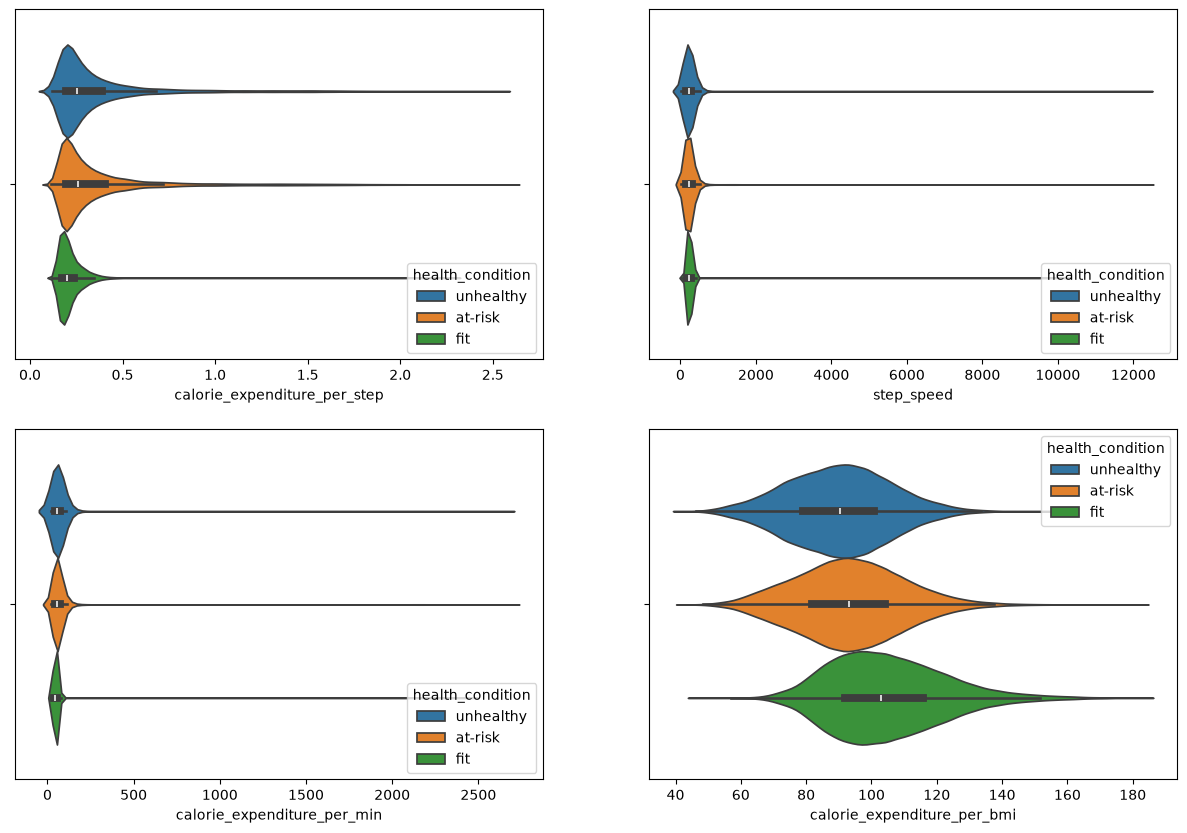

In [7]:
fig, axs = plt.subplots(figsize=(15,10),nrows=2, ncols=2)

sns.violinplot(df, x="calorie_expenditure_per_step",hue=target_column,ax=axs[0][0])
sns.violinplot(df, x="step_speed",hue=target_column,ax=axs[0][1])
sns.violinplot(df, x="calorie_expenditure_per_min",hue=target_column,ax=axs[1][0])
sns.violinplot(df, x="calorie_expenditure_per_bmi",hue=target_column,ax=axs[1][1])

<Axes: xlabel='calorie_expenditure_per_bmi', ylabel='Count'>

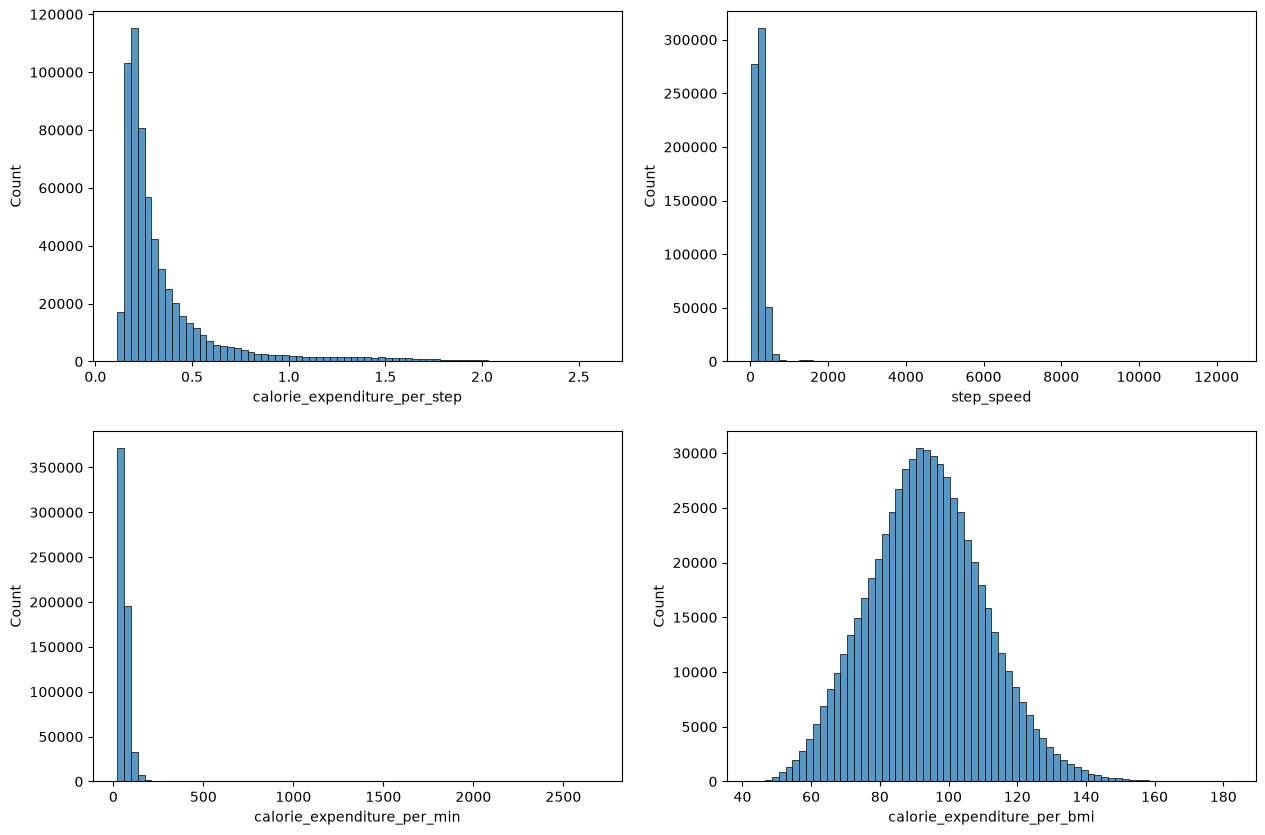

In [8]:
fig, axs = plt.subplots(figsize=(15,10),nrows=2, ncols=2)

sns.histplot(df, x="calorie_expenditure_per_step",ax=axs[0][0],bins=70)
sns.histplot(df, x="step_speed",ax=axs[0][1],bins=70)
sns.histplot(df, x="calorie_expenditure_per_min",ax=axs[1][0],bins=70)
sns.histplot(df, x="calorie_expenditure_per_bmi",ax=axs[1][1],bins=70)

In [9]:
y = df[target_column].replace({'unhealthy':0, 'at-risk':1, 'fit':2}).astype('int')
X = df.drop(target_column, axis=1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
df_test = pd.read_csv("data/test.csv")

df_submission = pd.read_csv("data/sample_submission.csv")
df_submission.info()

<class 'pandas.DataFrame'>
RangeIndex: 295753 entries, 0 to 295752
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   id                295753 non-null  int64
 1   health_condition  295753 non-null  str  
dtypes: int64(1), str(1)
memory usage: 4.5 MB


In [ ]:
df_test['diet_type'] = df_test['diet_type'].astype('category')
df_test['stress_level'] = df_test['stress_level'].replace({'low':0, 'medium':1, 'high':2})
df_test['sleep_quality'] = df_test['sleep_quality'].replace({'poor':0, 'average':1, 'good':2})
df_test['physical_activity_level'] = df_test['physical_activity_level'].replace({'sedentary':0, 'moderate':1, 'active':2})
df_test['smoking_alcohol'] = df_test['smoking_alcohol'].replace({'no':0, 'occasional':1, 'yes':2})
df_test['gender'] = df_test['gender'].astype('category')

object_cols = ['stress_level', 'sleep_quality', 'physical_activity_level', 'smoking_alcohol']
for col in object_cols:
    df_test[col] = df_test[col].astype('category')

df_test['calorie_expenditure_per_step'] = df_test['calorie_expenditure'] / (df_test['step_count']+1)
df_test['step_speed'] = df_test['step_count'] / (df_test['exercise_duration']+1)
df_test['calorie_expenditure_per_min'] = df_test['calorie_expenditure'] / (df_test['exercise_duration']+1)
df_test['calorie_expenditure_per_bmi'] = df_test['calorie_expenditure'] / (df_test['bmi']+1)

In [18]:
sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

model = XGBClassifier(booster='gbtree', num_class=3, objective='multi:softprob', tree_method='hist', enable_categorical=True, early_stopping_rounds=100, n_estimators=100, max_depth=8, learning_rate=0.05)
model.fit(X_train, y_train, sample_weight=sample_weight, eval_set=[(X_test, y_test)])

joblib.dump(model, 'models/xgboost_tts_80.pkl')

[0]	validation_0-mlogloss:1.03595
[1]	validation_0-mlogloss:0.98037
[2]	validation_0-mlogloss:0.92943
[3]	validation_0-mlogloss:0.88259
[4]	validation_0-mlogloss:0.83940
[5]	validation_0-mlogloss:0.79949
[6]	validation_0-mlogloss:0.76253
[7]	validation_0-mlogloss:0.72815
[8]	validation_0-mlogloss:0.69619
[9]	validation_0-mlogloss:0.66642
[10]	validation_0-mlogloss:0.63867
[11]	validation_0-mlogloss:0.61275
[12]	validation_0-mlogloss:0.58854
[13]	validation_0-mlogloss:0.56585
[14]	validation_0-mlogloss:0.54462
[15]	validation_0-mlogloss:0.52472
[16]	validation_0-mlogloss:0.50603
[17]	validation_0-mlogloss:0.48850
[18]	validation_0-mlogloss:0.47205
[19]	validation_0-mlogloss:0.45657
[20]	validation_0-mlogloss:0.44200
[21]	validation_0-mlogloss:0.42828
[22]	validation_0-mlogloss:0.41537
[23]	validation_0-mlogloss:0.40321
[24]	validation_0-mlogloss:0.39175
[25]	validation_0-mlogloss:0.38095
[26]	validation_0-mlogloss:0.37075
[27]	validation_0-mlogloss:0.36112
[28]	validation_0-mlogloss:0.3

['models/xgboost_tts_80.pkl']

In [46]:
def objective(trial):
    params = {
        "verbosity": 0,
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=100),
        'max_depth': trial.suggest_int('max_depth', 2, 20, step=3),
        'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 1.0),
        "booster": trial.suggest_categorical("booster", ["gbtree", "dart"]),
        "lambda": trial.suggest_float("lambda", 1e-8, 1.0, log=True),
        "alpha": trial.suggest_float("alpha", 1e-8, 1.0, log=True),
        "eta": trial.suggest_float("eta", 1e-8, 1.0, log=True),
        "gamma": trial.suggest_float("gamma", 1e-8, 1.0, log=True),
    }

    sample_weight = compute_sample_weight(class_weight="balanced", y=y_train)

    model = XGBClassifier(num_class=3, objective='multi:softprob', tree_method='hist', enable_categorical=True, early_stopping_rounds=100, **params)
    model.fit(X_train, y_train, sample_weight=sample_weight, eval_set=[(X_test, y_test)])

    sample_weight = compute_sample_weight(class_weight="balanced", y=y_test)
    val_score = model.score(X_test, y_test, sample_weight=sample_weight)
    return val_score

In [ ]:
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20)

sample_weight = compute_sample_weight(class_weight="balanced", y=y)

best_params = study.best_params
best_model = XGBClassifier(num_class=3, objective='multi:softprob', tree_method='hist', enable_categorical=True, **best_params)
best_model.fit(X, y, sample_weight=sample_weight)

y_pred = best_model.predict(df_test)

df_submission[target_column] = y_pred
df_submission[target_column] = df_submission[target_column].replace({0:'unhealthy', 1:'at-risk', 2: 'fit'})
df_submission.info()

[I 2026-07-13 15:01:08,920] A new study created in memory with name: no-name-6644cf4a-b612-4193-ad34-c65c5134481d


[0]	validation_0-mlogloss:1.08233
[1]	validation_0-mlogloss:1.06854
[2]	validation_0-mlogloss:1.05835
[3]	validation_0-mlogloss:1.04744
[4]	validation_0-mlogloss:1.03374
[5]	validation_0-mlogloss:1.02261
[6]	validation_0-mlogloss:1.00884
[7]	validation_0-mlogloss:0.99837
[8]	validation_0-mlogloss:0.98581
[9]	validation_0-mlogloss:0.97588
[10]	validation_0-mlogloss:0.96622
[11]	validation_0-mlogloss:0.95391
[12]	validation_0-mlogloss:0.94340
[13]	validation_0-mlogloss:0.93309
[14]	validation_0-mlogloss:0.92239
[15]	validation_0-mlogloss:0.91032
[16]	validation_0-mlogloss:0.89849
[17]	validation_0-mlogloss:0.88938
[18]	validation_0-mlogloss:0.87961
[19]	validation_0-mlogloss:0.86932
[20]	validation_0-mlogloss:0.86020
[21]	validation_0-mlogloss:0.84962
[22]	validation_0-mlogloss:0.83943
[23]	validation_0-mlogloss:0.83069
[24]	validation_0-mlogloss:0.82203
[25]	validation_0-mlogloss:0.81175
[26]	validation_0-mlogloss:0.80194
[27]	validation_0-mlogloss:0.79201
[28]	validation_0-mlogloss:0.7

[I 2026-07-13 15:18:30,621] Trial 0 finished with value: 0.9152005141373948 and parameters: {'n_estimators': 1000, 'max_depth': 20, 'learning_rate': 0.011744262270071774, 'subsample': 0.6232277890242661, 'colsample_bytree': 0.8671639606067882, 'booster': 'gbtree', 'lambda': 0.010426470991623768, 'alpha': 3.475427592621078e-08, 'eta': 2.3999559865884487e-06, 'gamma': 1.7739915848964405e-08}. Best is trial 0 with value: 0.9152005141373948.


[0]	validation_0-mlogloss:1.09556
[1]	validation_0-mlogloss:1.09434
[2]	validation_0-mlogloss:1.09325
[3]	validation_0-mlogloss:1.09255
[4]	validation_0-mlogloss:1.09055
[5]	validation_0-mlogloss:1.08845
[6]	validation_0-mlogloss:1.08668
[7]	validation_0-mlogloss:1.08588
[8]	validation_0-mlogloss:1.08534
[9]	validation_0-mlogloss:1.08449
[10]	validation_0-mlogloss:1.08240
[11]	validation_0-mlogloss:1.08077
[12]	validation_0-mlogloss:1.07890
[13]	validation_0-mlogloss:1.07728
[14]	validation_0-mlogloss:1.07624
[15]	validation_0-mlogloss:1.07329
[16]	validation_0-mlogloss:1.07005
[17]	validation_0-mlogloss:1.06869
[18]	validation_0-mlogloss:1.06668
[19]	validation_0-mlogloss:1.06543
[20]	validation_0-mlogloss:1.06321
[21]	validation_0-mlogloss:1.06177
[22]	validation_0-mlogloss:1.05925
[23]	validation_0-mlogloss:1.05827
[24]	validation_0-mlogloss:1.05691
[25]	validation_0-mlogloss:1.05592
[26]	validation_0-mlogloss:1.05517
[27]	validation_0-mlogloss:1.05370
[28]	validation_0-mlogloss:1.0

[I 2026-07-13 15:24:30,889] Trial 1 finished with value: 0.9305738302463556 and parameters: {'n_estimators': 500, 'max_depth': 14, 'learning_rate': 0.0030522195830293168, 'subsample': 0.5591474483500877, 'colsample_bytree': 0.358322450855061, 'booster': 'gbtree', 'lambda': 0.004400869105293913, 'alpha': 0.00010001519019385094, 'eta': 0.4795143663919391, 'gamma': 1.2296117042107702e-05}. Best is trial 1 with value: 0.9305738302463556.


...

[0]	validation_0-mlogloss:1.05164
[1]	validation_0-mlogloss:0.99951
[2]	validation_0-mlogloss:0.97129
[3]	validation_0-mlogloss:0.95702
[4]	validation_0-mlogloss:0.91498
[5]	validation_0-mlogloss:0.86851
[6]	validation_0-mlogloss:0.82564
[7]	validation_0-mlogloss:0.80682
[8]	validation_0-mlogloss:0.79689
[9]	validation_0-mlogloss:0.79005
[10]	validation_0-mlogloss:0.75742
[11]	validation_0-mlogloss:0.70952
[12]	validation_0-mlogloss:0.67901
[13]	validation_0-mlogloss:0.66346
[14]	validation_0-mlogloss:0.65146
[15]	validation_0-mlogloss:0.61186
[16]	validation_0-mlogloss:0.56678
[17]	validation_0-mlogloss:0.54638
[18]	validation_0-mlogloss:0.52709
[19]	validation_0-mlogloss:0.51516
[20]	validation_0-mlogloss:0.48929
[21]	validation_0-mlogloss:0.47744
[22]	validation_0-mlogloss:0.45914
[23]	validation_0-mlogloss:0.45122
[24]	validation_0-mlogloss:0.44289
[25]	validation_0-mlogloss:0.43300
[26]	validation_0-mlogloss:0.42277
[27]	validation_0-mlogloss:0.39932
[28]	validation_0-mlogloss:0.3

[I 2026-07-13 16:29:55,200] Trial 18 finished with value: 0.9357937157450856 and parameters: {'n_estimators': 300, 'max_depth': 11, 'learning_rate': 0.09679407911927926, 'subsample': 0.7326953003771745, 'colsample_bytree': 0.4324245141110264, 'booster': 'dart', 'lambda': 0.9513786486987998, 'alpha': 0.23524473241021976, 'eta': 1.4162583392550051e-05, 'gamma': 0.0037475969429642216}. Best is trial 16 with value: 0.9506579965535187.


[0]	validation_0-mlogloss:1.08600
[1]	validation_0-mlogloss:1.07508
[2]	validation_0-mlogloss:1.06734
[3]	validation_0-mlogloss:1.05957
[4]	validation_0-mlogloss:1.04726
[5]	validation_0-mlogloss:1.03928
[6]	validation_0-mlogloss:1.02759
[7]	validation_0-mlogloss:1.01946
[8]	validation_0-mlogloss:1.00945
[9]	validation_0-mlogloss:1.00332
[10]	validation_0-mlogloss:0.99387
[11]	validation_0-mlogloss:0.98262
[12]	validation_0-mlogloss:0.97305
[13]	validation_0-mlogloss:0.96447
[14]	validation_0-mlogloss:0.95704
[15]	validation_0-mlogloss:0.94463
[16]	validation_0-mlogloss:0.93179
[17]	validation_0-mlogloss:0.92346
[18]	validation_0-mlogloss:0.91435
[19]	validation_0-mlogloss:0.90467
[20]	validation_0-mlogloss:0.89511
[21]	validation_0-mlogloss:0.88445
[22]	validation_0-mlogloss:0.87475
[23]	validation_0-mlogloss:0.86699
[24]	validation_0-mlogloss:0.85881
[25]	validation_0-mlogloss:0.85291
[26]	validation_0-mlogloss:0.84494
[27]	validation_0-mlogloss:0.83443
[28]	validation_0-mlogloss:0.8

[I 2026-07-13 16:30:38,321] Trial 19 finished with value: 0.9501821417517078 and parameters: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.013561362781511339, 'subsample': 0.6665081700028613, 'colsample_bytree': 0.732520279995074, 'booster': 'gbtree', 'lambda': 3.8145303634046205e-05, 'alpha': 3.960382757661817e-05, 'eta': 0.021752779427400552, 'gamma': 0.1546551303667975}. Best is trial 16 with value: 0.9506579965535187.


<class 'pandas.DataFrame'>
RangeIndex: 295753 entries, 0 to 295752
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   id                295753 non-null  int64 
 1   health_condition  295753 non-null  object
dtypes: int64(1), object(1)
memory usage: 4.5+ MB


In [48]:
joblib.dump(best_model, 'models/xgboost_optuna.pkl')
df_submission.to_csv('results/xgboost_optuna.csv', index=False)
df_submission

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy
...,...,...
295748,985836,fit
295749,985837,at-risk
295750,985838,unhealthy
295751,985839,at-risk
